In [1]:
import nbimporter
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from torch import nn
from torch.optim import SGD
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from os.path import join
import torch
import numpy as np
from PIL import Image
from os import path

import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

import matplotlib.pyplot as plt

from python_file.dirPath import csvDir, imageDir, Test, historiesDir

np.random.seed(1328)
torch.random.manual_seed(1328)

In [2]:
#resize normale
tran = transforms.Compose([StreetSign.Rescale(32),StreetSign.RandomCrop(32),StreetSign.ToTensor()])

In [3]:
datatrain = StreetSign.StreetSignDataset(csvDir / 'classes.csv',imageDir,tran)
datatest = StreetSign.StreetSignTest( Test / 'prova.txt',Test,tran)

In [4]:
datatrain_loader = DataLoader(datatrain, batch_size=1024, shuffle=True)
datatest_loader = DataLoader(datatest, batch_size=1024, shuffle=True)

<h1>Versione di prova con 5 epoche solo per test rapidi</h1>

In [6]:
#number of epoch
epoche = 5
momento = 0.3
learning_rate=0.001
exp_name='minialexnetV2'
outModel = f'{exp_name}_lr{learning_rate}_m{momento}'

In [7]:
minialexnetV2_datatrain = Network.MiniAlexNetV2()

minialexnetV2_datatrain = Function.train_classifier(minialexnetV2_datatrain, datatrain_loader, datatest_loader, \
                                                    outModel, learning_rate, epoche, momento, save_model=True)

minialexnetV2_data_test_probabilities, data_labels_test = Function.test_classifier(minialexnetV2_datatrain,
                                                                                   datatest_loader)

data_labels_test

array([1, 1, 0, 1, 1, 1, 0, 0, 2, 2, 1, 0, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1,
       1, 1, 0, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1,
       1, 0, 0, 0, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 0, 2, 2, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 2, 2, 1, 0, 1, 0, 0, 1, 1, 0, 2, 1, 2, 2, 1, 1,
       2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1,
       1, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1,
       2, 1, 1, 2, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 1, 2, 2, 2, 2, 1, 1, 2,
       2, 2, 1, 1, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1, 2, 0, 1, 1, 1, 1, 2, 1, 2,
       1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 0, 2, 0, 1, 0, 2, 1, 1,
       2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       2, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2,

In [7]:
print(f"Shape probabilità: {minialexnetV2_data_test_probabilities.shape}")
print(f"Classi uniche nelle etichette: {np.unique(data_labels_test)}")

Shape probabilità: (475, 4)
Classi uniche nelle etichette: [0 1 2]


In [8]:
file_csv = historiesDir / f'{exp_name}-{epoche}.csv'

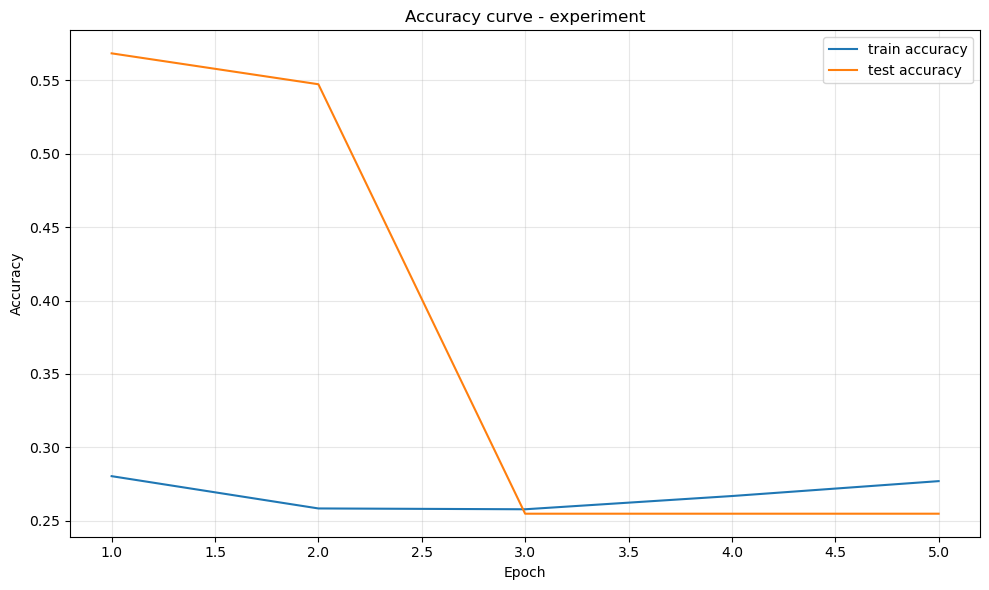

In [9]:
Function.plot_accuracy_from_csv(file_csv , "Accuracy curve - experiment")

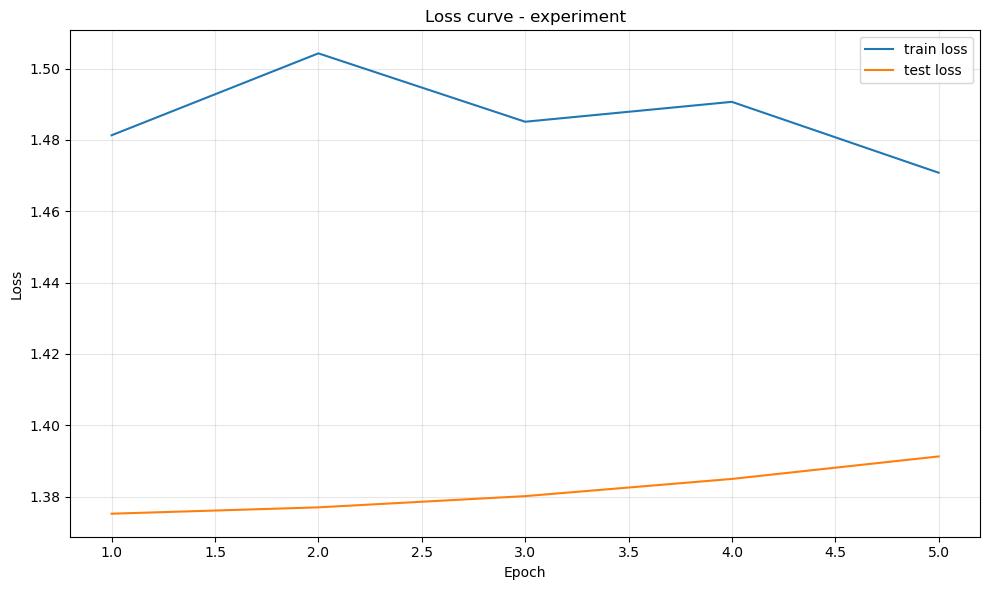

In [10]:
Function.plot_loss_from_csv(file_csv, "Loss curve - experiment")

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.522
  Classe 1: 0.582
  Classe 2: 0.561

AUC macro (media): 0.555


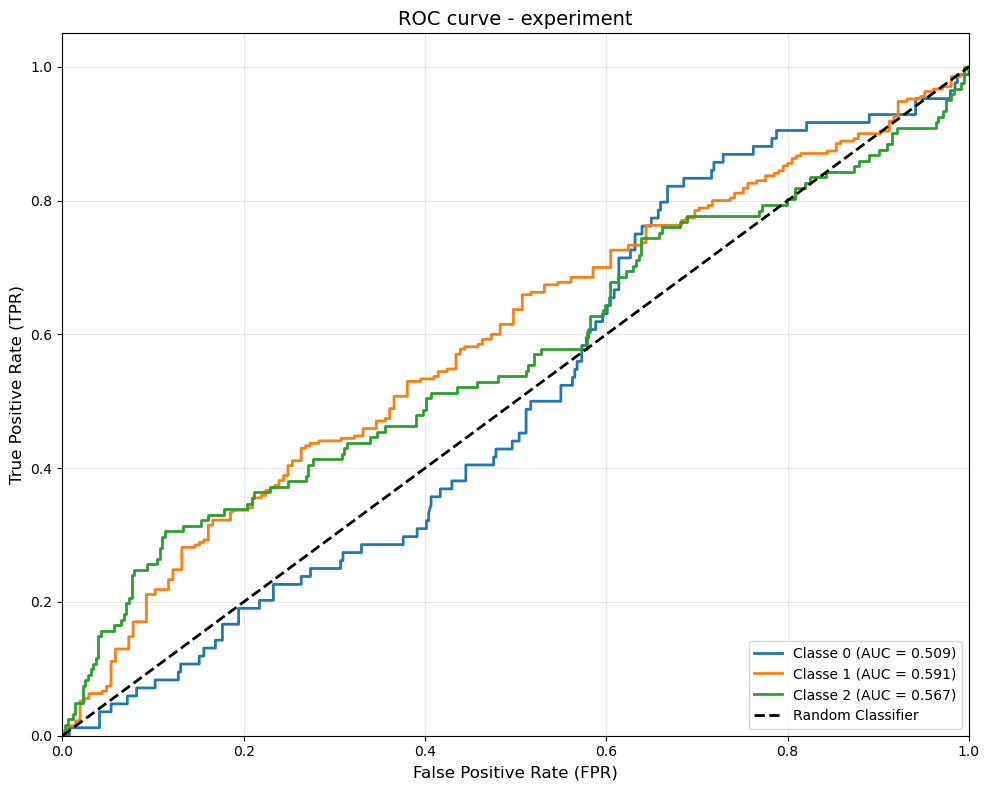

In [11]:
Function.plot_roc_curve(data_labels_test, minialexnetV2_data_test_probabilities, "ROC curve - experiment")

<h1>Test a 1200 epoche</h1>

In [28]:
#number of epoch
epoche = 1200
momento = 0.6
learning_rate=0.0001
exp_name='minialexnetV2_dataset'

In [29]:
minialexnetV2_datatrain = Network.MiniAlexNetV2()

minialexnetV2_datatrain = Function.train_classifier(minialexnetV2_datatrain, datatrain_loader, datatest_loader, \
                                                    exp_name, learning_rate, epoche, momento, save_model=True)

minialexnetV2_data_test_probabilities, data_labels_test = Function.test_classifier(minialexnetV2_datatrain,
                                                                                   datatest_loader)

data_labels_test

array([2, 1, 1, 1, 1, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 2, 1, 2, 1, 1, 0, 1,
       0, 2, 2, 0, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 2,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 0,
       1, 2, 1, 1, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 2, 0, 1, 2, 1, 1, 1,
       1, 2, 0, 1, 2, 1, 2, 0, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 2,
       1, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1,
       2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1,
       1, 2, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 0, 2, 1, 0,
       1, 2, 2, 1, 2, 2, 1, 1, 0, 2, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 2, 1, 2, 1, 1, 1, 0, 1, 0, 2, 2, 1, 0, 1, 0, 2, 0, 2, 1,
       1, 2, 2, 2, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 0,

In [43]:
file_csv = historiesDir / f'{exp_name}-{epoche}.csv'

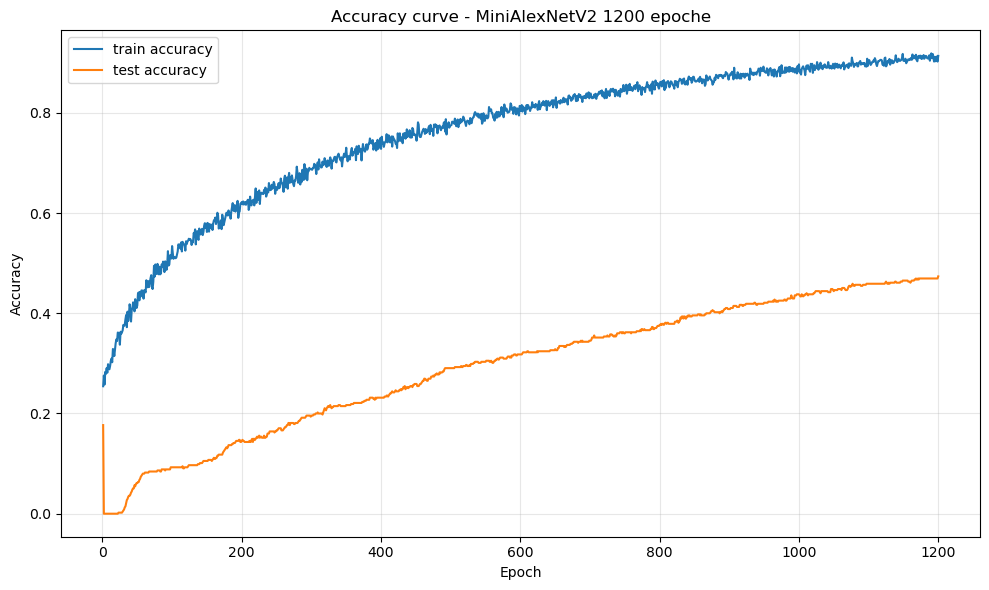

In [44]:
Function.plot_accuracy_from_csv(file_csv , "Accuracy curve - MiniAlexNetV2 1200 epoche")

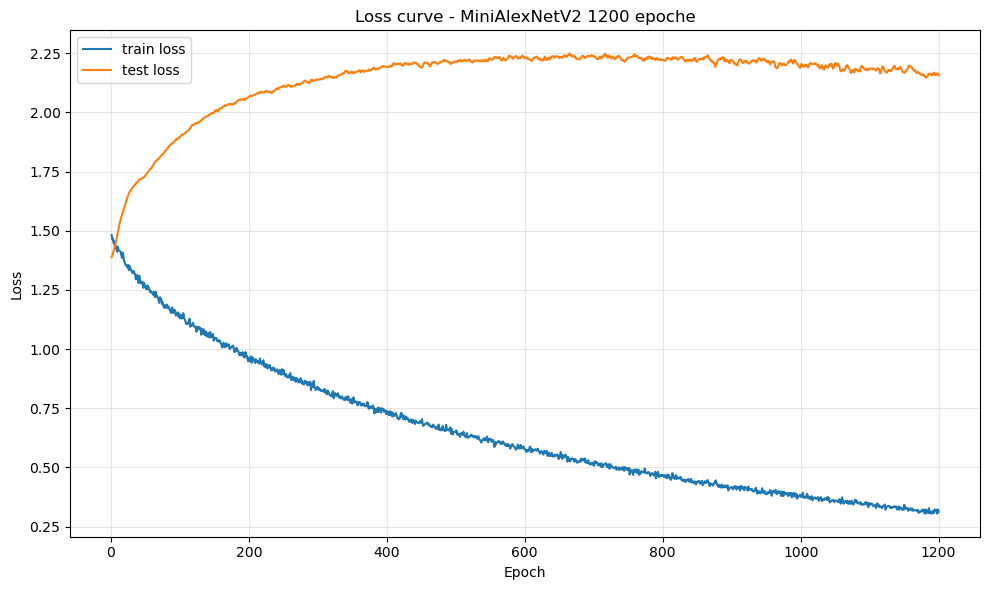

In [45]:
Function.plot_loss_from_csv(file_csv, "Loss curve - MiniAlexNetV2 1200 epoche")

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.834
  Classe 1: 0.839
  Classe 2: 0.900

AUC macro (media): 0.858


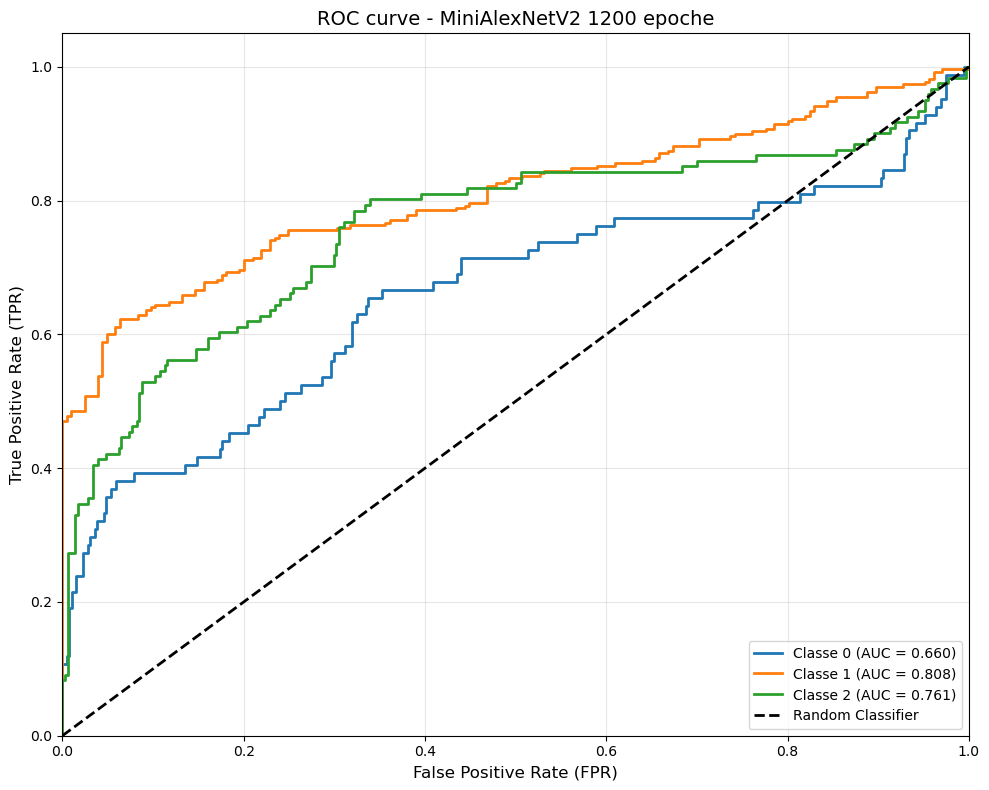

In [46]:
Function.plot_roc_curve(data_labels_test, minialexnetV2_data_test_probabilities, "ROC curve - MiniAlexNetV2 1200 epoche")